Ari Mononen - Neural Networks for Computer Vision

In [2]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from tempfile import TemporaryDirectory
import math

cudnn.benchmark = True
plt.ion()

In [3]:
print("CUDA saatavilla:", torch.cuda.is_available())
print("PyTorch-versio:", torch.__version__)

CUDA saatavilla: False
PyTorch-versio: 2.14.0+cpu


In [4]:
# Data-augmentaatio ja normalisointi opetussetille (estää ylisovittamista / overfitting).
# Validointi- ja testitestille tehdään vain muodon muutos ja normalisointi reilun arvioinnin takaamiseksi.

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(299), # Nostetaan resoluutio 299x299 pikkutarkkojen yksityiskohtien (kuten lehtisuonten) erottamiseksi
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(degrees=15), # Lisätty satunnainen rotaatio (-15 ... +15 astetta) asentovaihtelun simuloimiseksi 
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Lisätty värisävyjen, kirkkauden ja kontrastin hienosäätö eri valaistusolosuhteiden simulointiin
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(320), # Skaalataan hieman 299 pikseliä suuremmaksi ennen keskeltä rajausta
        transforms.CenterCrop(299), # Rajataan täsmälleen 299x299 kokoon
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(320),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Datasetti on jaettu train, val ja test osuuksiin jo valmiiksi
data_dir = 'tree'
splits = ['train', 'val', 'test']

# Ladataan kuva-aineisto kansiorakenteen perusteella
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in splits}

# Luodaan Dataloader-olion, jotka syöttävät dataa batcheissä mallille
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=32,
                                             shuffle=(x == 'train'), num_workers=4)
              for x in splits}

dataset_sizes = {x: len(image_datasets[x]) for x in splits}
class_names = image_datasets['train'].classes

# Valitaan suoritin: GPU (CUDA), jos saatavilla, muuten CPU
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
print(f"Löytyi {len(class_names)} luokkaa.")

Using cpu device
Löytyi 23 luokkaa.


In [5]:
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

In [6]:
# Tämä funktio kouluttaa neuroverkkomallin ja tallentaa parhaan val-tarkkuuden saavuttaneet painoarvot.

def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()

    # Käytetään väliaikaishakemistoa parhaan mallin painojen tallentamiseen koulutuksen aikana
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Jokainen epookki sisältää opetus- ja valintavaiheen
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Asettaa mallin opetustilaan
                else:
                    model.eval()   # Asettaa mallin arviointitilaan

                running_loss = 0.0
                running_corrects = 0

                # Käydään läpi kaikki datasetin erät (batches)
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # Nollataan gradientit ennen uutta laskentakierrosta
                    optimizer.zero_grad()

                    # Gradienttien laskenta suoritetaan vain opetusvaiheessa muistin säästämiseksi
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # Takaisinlevitys (backpropagation) ja optimointi vain opetustilassa
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # Tilastot
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)

                # Päivitetään learning ratea opetusepookin jälkeen
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # Jos val-tarkkuus on paras tähän asti, tallennetaan mallin painot
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [7]:
# Visualisoi mallin tekemiä ennusteita. Muuntaa normalisoidut pytorch-tensorit takaisin katselukelpoisiksi kuviksi.

def visualize_model(model, num_images=23, split='val'):
    was_training = model.training
    model.eval()
    images_so_far = 0

    # Laitetaan kuvat 5 sarakkeeseen (23 kuvalle tulee 5 riviä)
    cols = 5
    rows = math.ceil(num_images / cols)
    fig = plt.figure(figsize=(10, 3 * rows))

    # Mean ja std kuvan palauttamiseksi normaaliksi
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders[split]):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(rows, cols, images_so_far)
                ax.axis('off')
                ax.set_title(f'pred: {class_names[preds[j]]}', fontsize=8)

                # Kuvan un-normalisointi ja piirto suoraan ruutuun
                inp = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                inp = std * inp + mean
                inp = np.clip(inp, 0, 1)
                ax.imshow(inp)

                if images_so_far == num_images:
                    plt.tight_layout()
                    plt.show()
                    model.train(mode=was_training)
                    return
                    
        plt.tight_layout()
        plt.show()
        model.train(mode=was_training)

In [8]:
# Laskee mallille monipuoliset suorituskykymetriikat testisetistä:
# - Classification Report (Precision, Recall, F1-score)
# - Confusion Matrix
# - Top-N Accuracy (Kuinka usein oikea luokka on N parhaan ennusteen joukossa)

def evaluate_model_on_test(model, split='test', topk_values=(1, 2, 3, 5)):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloaders[split]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.vstack(all_probs)

    # 1. Perusmetriikat (Accuracy, Precision, Recall, F1)
    print("=== CLASSIFICATION REPORT ===")
    print(
        classification_report(
            all_labels, all_preds, target_names=class_names, digits=4
        )
    )

    # 2. Confusion Matrix
    print("=== CONFUSION MATRIX ===")
    cm = confusion_matrix(all_labels, all_preds)
    print(cm)

    # 3. Top-N tulokset
    print("\n=== TOP-N ACCURACIES ===")
    for k in topk_values:
        # Tarkistetaan löytyykö oikea luokka top-k ennusteista
        topk_preds = np.argsort(all_probs, axis=1)[:, -k:]
        correct = sum(
            [
                all_labels[i] in topk_preds[i]
                for i in range(len(all_labels))
            ]
        )
        topk_acc = correct / len(all_labels)
        print(f'Top-{k} Accuracy: {topk_acc:.4f}')

# ResNet18-malli:

In [9]:
# Transfer Learning ja ResNet18-mallin alustus:

# Ladataan valmiiksi koulutettu ResNet18-malli
model_resnet18 = models.resnet18(weights='IMAGENET1K_V1')

# Vaihdetaan mallin viimeinen fully connected kerros vastaamaan oman aineistomme 23:a luokkamäärää
num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, len(class_names))

# Siirretään malli laskentalaitteelle
model_resnet18 = model_resnet18.to(device)

# Määritetään loss function, optimizer ja learning rate
criterion = nn.CrossEntropyLoss()
optimizer_resnet18 = optim.SGD(model_resnet18.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_resnet18, step_size=7, gamma=0.1)

In [10]:
# ResNet18-mallin koulutus:

model_resnet18 = train_model(model_resnet18, criterion, optimizer_resnet18, exp_lr_scheduler,
                       num_epochs=10)

Epoch 0/9
----------
train Loss: 2.9210 Acc: 0.1499
val Loss: 2.2782 Acc: 0.4129

Epoch 1/9
----------
train Loss: 2.1236 Acc: 0.4195
val Loss: 1.3863 Acc: 0.6141

Epoch 2/9
----------
train Loss: 1.5472 Acc: 0.5694
val Loss: 1.0186 Acc: 0.7012

Epoch 3/9
----------
train Loss: 1.2635 Acc: 0.6371
val Loss: 0.8698 Acc: 0.7490

Epoch 4/9
----------
train Loss: 1.0777 Acc: 0.6878
val Loss: 0.6886 Acc: 0.8071

Epoch 5/9
----------
train Loss: 0.9487 Acc: 0.7242
val Loss: 0.5691 Acc: 0.8320

Epoch 6/9
----------
train Loss: 0.9000 Acc: 0.7281
val Loss: 0.6102 Acc: 0.8091

Epoch 7/9
----------
train Loss: 0.7841 Acc: 0.7704
val Loss: 0.4457 Acc: 0.8714

Epoch 8/9
----------
train Loss: 0.7238 Acc: 0.7977
val Loss: 0.4163 Acc: 0.8942

Epoch 9/9
----------
train Loss: 0.6975 Acc: 0.8034
val Loss: 0.4217 Acc: 0.8797

Training complete in 315m 23s
Best val Acc: 0.894191


In [11]:
# Ajo ResNet-18:sta

print("---------------- ResNet-18 TEST TULOKSET ----------------")
evaluate_model_on_test(model_resnet18, split='test')

---------------- ResNet-18 TEST TULOKSET ----------------
=== CLASSIFICATION REPORT ===
                                   precision    recall  f1-score   support

                    Acer palmatum     0.7273    0.8000    0.7619        20
                   Cedrus deodara     0.9375    1.0000    0.9677        15
                  Celtis sinensis     0.7143    0.6522    0.6818        23
 Cinnamomum camphora (Linn) Presl     0.8667    0.8966    0.8814        29
            Elaeocarpus decipiens     0.6400    0.7619    0.6957        21
                 Flowering cherry     0.8333    0.3846    0.5263        13
                    Ginkgo biloba     0.8333    0.7143    0.7692        28
          Koelreuteria paniculata     0.9091    0.7143    0.8000        28
             Lagerstroemia indica     0.7000    0.8750    0.7778         8
            Liquidambar formosana     0.8889    0.8000    0.8421        20
            Liriodendron chinense     0.5938    0.8636    0.7037        22
           

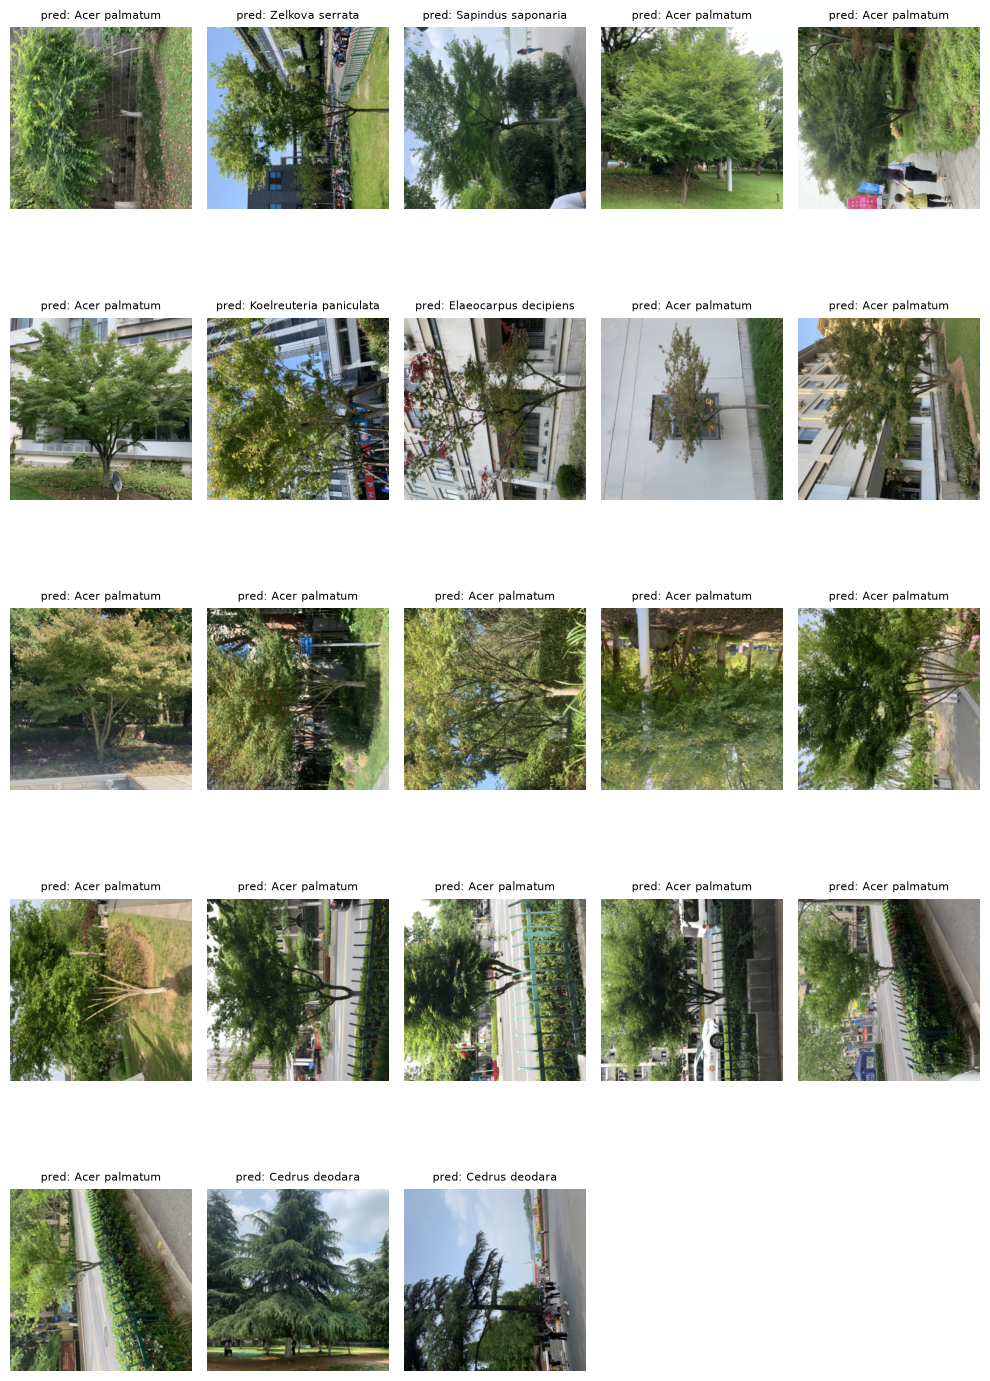

In [12]:
# Printtaa 23 kuvaa ResNet18-mallin validation-setistä:

visualize_model(model_resnet18, num_images=23, split='val')

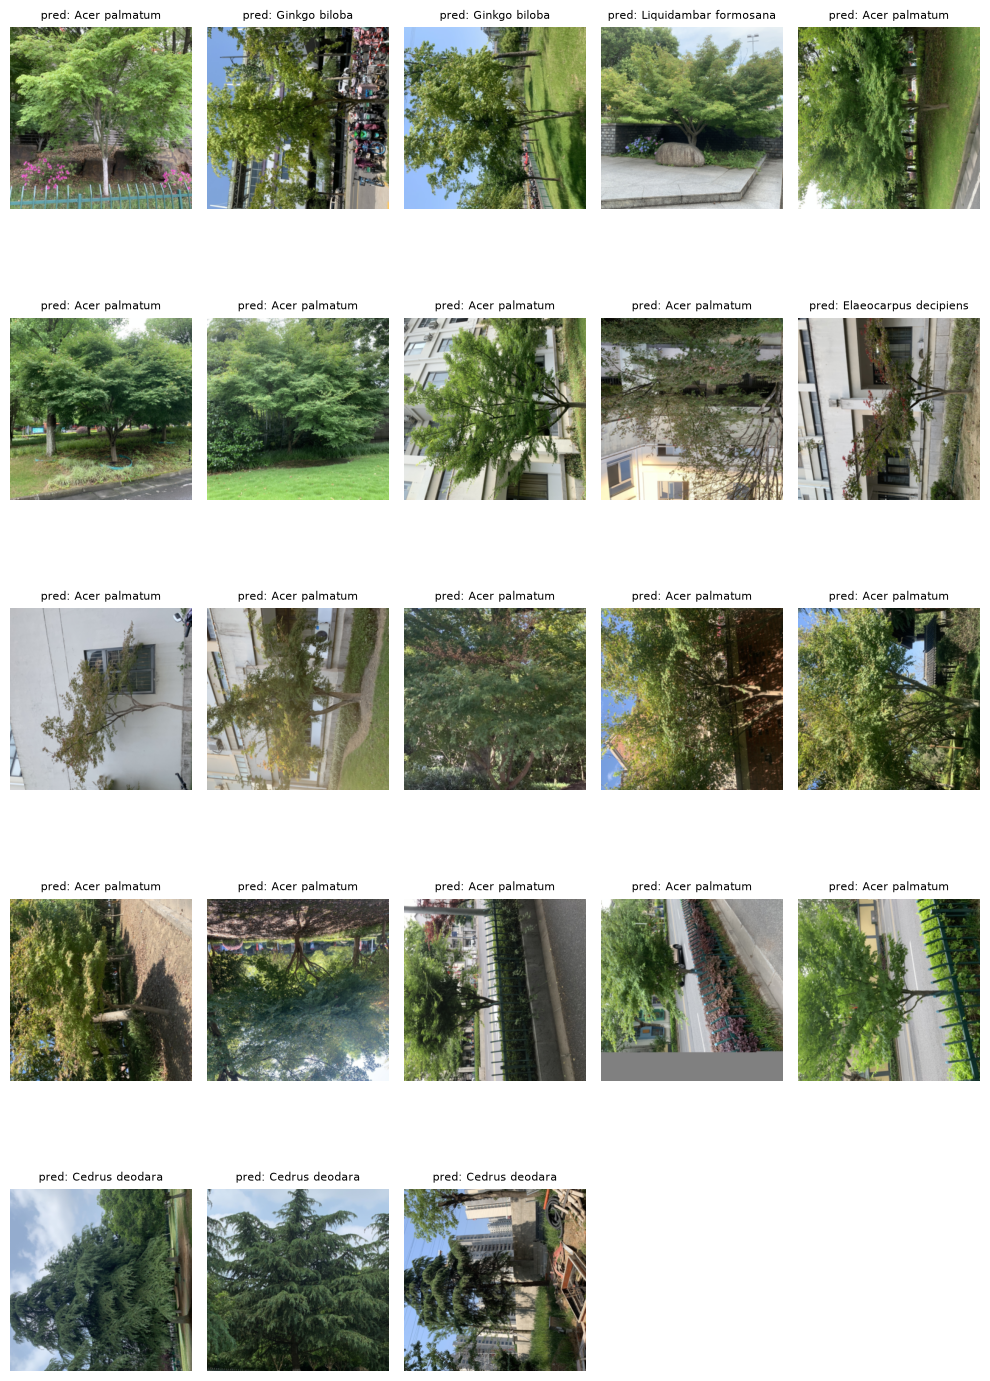

In [13]:
# Printtaa 23 kuvaa ResNet18-mallin test-setistä:

visualize_model(model_resnet18, num_images=23, split='test')

# ResNet50-malli:

In [14]:
# Transfer Learning ja ResNet50-mallin alustus:

# Ladataan valmiiksi koulutettu ResNet50-malli
model_resnet50 = models.resnet50(weights='IMAGENET1K_V1')

# Vaihdetaan mallin viimeinen fully connected kerros vastaamaan oman aineistomme 23:a luokkamäärää
num_ftrs = model_resnet50.fc.in_features
model_resnet50.fc = nn.Linear(num_ftrs, len(class_names))

# Siirretään malli laskentalaitteelle
model_resnet50 = model_resnet50.to(device)

# Määritetään loss function, optimizer ja learning rate
criterion = nn.CrossEntropyLoss()
optimizer_resnet50 = optim.SGD(model_resnet50.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_resnet50, step_size=7, gamma=0.1)

In [ ]:
# ResNet50-mallin koulutus:

model_resnet50 = train_model(model_resnet50, criterion, optimizer_resnet50,
                         exp_lr_scheduler, num_epochs=10)

Epoch 0/9
----------
train Loss: 2.9094 Acc: 0.1597
val Loss: 2.2335 Acc: 0.4398

Epoch 1/9
----------


In [ ]:
# Ajo ResNet-50:sta

print("\n---------------- ResNet-50 TEST TULOKSET ----------------")
evaluate_model_on_test(model_resnet50, split='test')

In [ ]:
# Printtaa 23 kuvaa ResNet50-mallin validation-setistä:

visualize_model(model_resnet50, num_images=23, split='val')

In [ ]:
# Printtaa 23 kuvaa ResNet50-mallin test-setistä:

visualize_model(model_resnet50, num_images=23, split='test')